If working in remote repository one mignht need to uncoomment and run next cell


In [7]:
# !pip insrall sympy numpy matplotlib

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy.plotting import plot

The integral we are tryinh to evaluate is given by:

\begin{align}
&\mathfrak{H}(\Omega)
= \int_{0}^{\infty} dq\; q
\int_{-\infty}^{\infty} d\Omega_{1}\;
q^{-13/3}
\exp\!\left(-2\Omega_{1}^{2}q^{-4/3}\right)
\nonumber\\
&\times \Bigg[
\left(\frac{27}{6}-\frac{1}{6q^{2}}\right)
I_{+1}(q,\Omega,\Omega_{1})
+\left(\frac{1}{12q^{2}}+\frac{q^{2}}{12}-\frac{1}{6}\right)
I_{-1}(q,\Omega,\Omega_{1})
+\frac{1}{12q^{2}}\,I_{+3}(q,\Omega,\Omega_{1})
\Bigg],
\end{align}

\begin{align}
I_{+1}(q,\Omega,\Omega_{1})
&\equiv \int_{|1-q|}^{1+q} ds\;
s^{-10/3}
\exp\!\left(-2(\Omega-\Omega_{1})^{2}s^{-4/3}\right),\\
I_{-1}(q,\Omega,\Omega_{1})
&\equiv \int_{|1-q|}^{1+q} ds\;
s^{-16/3}
\exp\!\left(-2(\Omega-\Omega_{1})^{2}s^{-4/3}\right),\\
I_{+3}(q,\Omega,\Omega_{1})
&\equiv \int_{|1-q|}^{1+q} ds\;
s^{-4/3}
\exp\!\left(-2(\Omega-\Omega_{1})^{2}s^{-4/3}\right).
\end{align}

## Checking equation A.1 gogberidze

In [12]:
sp.init_printing()  # for better display of mathematical expressions


## Compontents 
kc1, kc2, kc3 = sp.symbols('k_c1 k_c2 k_c3')
x1, x2, x3 = sp.symbols('x_1 x_2 x_3')

kvec = sp.Matrix([kc1, kc2, kc3])
xvec = sp.Matrix([x1, x2, x3])

xdotk = xvec.dot(kvec)
ksq = kvec.dot(kvec)
kmag = sp.sqrt(ksq)


## setting up symbols 
kd, k0, k, k1 = sp.symbols('k_d k_0 k k_1')  
eps, Ck, etak = sp.symbols('epsilon C_k eta_k')  
t,x = sp.symbols('t x')  
Ak = sp.symbols('A_k')  
f = sp.symbols("f")
Rij, Fij = sp.symbols('R_ij F_ij')
Pij = sp.symbols('Pij')  
Ek = sp.symbols('E_k')  

## setting up functions
Ek = sp.Function('E_k')(k)  
Rij = sp.Function('R_ij')(x,t)  
Fij = sp.Function('F_ij')(k,t)
etak = sp.Function('eta_k')(k)
Ak = sp.Function('A_k')(k)  
f = sp.Function("f")(k,t)
Pij = sp.Function('P_ij')(k)

## defining the functions
etak = 1/ (sp.sqrt(2 * sp.pi)) * eps ** sp.Rational(1,3) *  k ** sp.Rational(2,3) # type: ignore
Ek = Ck * eps  * k ** (sp.Rational(-5,3))
Ak = Ck * eps **(sp.Rational(2,3)) * k ** (sp.Rational(-11,3))/ (sp.pi * 4)
f = sp.exp(sp.pi / (-4) * etak ** 2 * t ** 2)
Pij = sp.eye(3) - kvec * kvec.T / ksq

Fij = Pij * Ak * f 


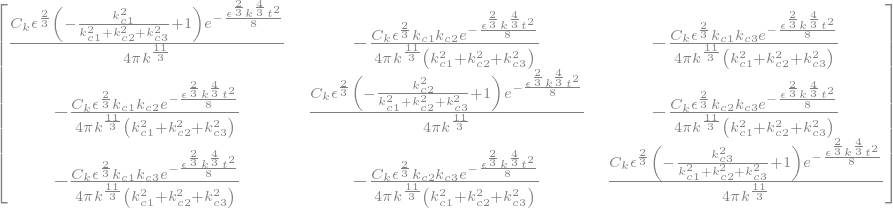

In [13]:
Fij

## Attempt 2 

In [17]:
## Setting up symbols

## Symbols for the problem 
kd, k0 = sp.symbols('k_d k_0')
etak = sp.symbols('eta_k')
Ck = sp.symbols('C_k')
eps = sp.symbols('epsilon')

## Integration symbols
# c here stand for component
# all the foureier sapce momentum variables
kc1, kc2, kc3 = sp.symbols('k_c1 k_c2 k_c3', real=True)
k1c1, k1c2, k1c3 = sp.symbols('k1_c1 k1_c2 k1_c3', real=True)
pc1, pc2, pc3 = sp.symbols('p_c1 p_c2 p_c3', real=True)
qc1, qc2, qc3 = sp.symbols('q_c1 q_c2 q_c3', real=True)

## magnitudes 
kmag, kmag1, pmag, qmag = sp.symbols('k k1 p q', positive=True, real=True)


# real sapace variables
nc1, nc2, nc3 = sp.symbols('n_c1 n_c2 n_c3', real=True)
xc1, xc2, xc3 = sp.symbols('x_c1 x_c2 x_c3', real=True)
r, theta, phi = sp.symbols('r theta phi')

n, x = sp.symbols('n x', real=True, positive=True)

# temporal variables
t, omega  = sp.symbols('t omega', real=True)



## Definig functions

In [ ]:
## setting up functions
etak = sp.Function('eta_k')(k)
Ak = sp.Function('A_k')(k)  
f = sp.Function("f")(k,t)
Pij = sp.Function('P_ij')(k)

## defining the functions
etak = 1/ (sp.sqrt(2 * sp.pi)) * eps ** sp.Rational(1,3) *  k ** sp.Rational(2,3) # type: ignore
Ek = Ck * eps  * k ** (sp.Rational(-5,3))
Ak = Ck * eps **(sp.Rational(2,3)) * k ** (sp.Rational(-11,3))/ (sp.pi * 4)
f = sp.exp(sp.pi / (-4) * etak ** 2 * t ** 2)
Pij = sp.eye(3) - kvec * kvec.T / ksq
